In [ ]:
# Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Loading Dataset
df = pd.read_csv("Portfolio Dataset.csv")

In [ ]:
X = df[['Temperature(°C)', 'AC hours', 'Fan hours',
        'Light hours']]
# Target Variable
y = df['Daily Consumption(kWh)']

In [ ]:
# Dataset Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("R2 Score:", round(r2_score(y_test, y_pred),2))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred),2))

R2 Score: 0.96
Mean Absolute Error: 0.16


In [ ]:
# Actual vs Predicted
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(results)

   Actual  Predicted
0    19.2  19.108338
1    16.9  16.778052
2    17.2  17.507384
3    18.6  18.706417
4    18.2  18.041389


**Prediction using new data**

In [ ]:
# Predicting New Data
new_data = pd.DataFrame({
    'Temperature(°C)': [35],
    'AC hours': [8],
    'Fan hours': [20],
    'Light hours': [12],
})


prediction = model.predict(new_data)

print("Predicted Daily Consumption:",
      round(prediction[0],2),"(kWh)")

Predicted Daily Consumption: 20.17 (kWh)


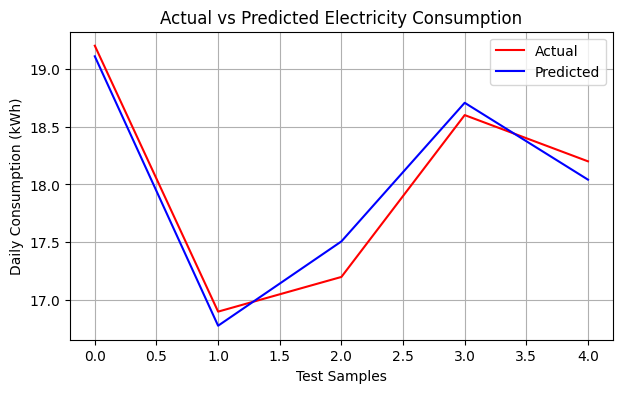

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(y_test.values, label="Actual", color='red')
plt.plot(y_pred, label="Predicted", color='blue')

plt.xlabel("Test Samples")
plt.ylabel("Daily Consumption (kWh)")
plt.title("Actual vs Predicted Electricity Consumption")
plt.legend()
plt.grid(True)

plt.show()

**Alert System**

In [ ]:
prediction = model.predict(new_data)

print("Predicted Daily Consumption:", round(prediction[0],2), "kWh")


if prediction[0] >= 21:
    print(" ALERT: High Electricity Consumption Expected!")
    print("Recommendation: Reduce AC usage, switch off unnecessary lights, and use energy-efficient appliances.")

elif prediction[0] >= 17:
    print(" Moderate Electricity Consumption Expected.")
    print("Recommendation: Monitor electricity usage and avoid unnecessary appliance usage.")

else:
    print(" Electricity Consumption is within the normal range.")

Predicted Daily Consumption: 20.17 kWh
 Moderate Electricity Consumption Expected.
Recommendation: Monitor electricity usage and avoid unnecessary appliance usage.
